***COLDCHAIN GUARD AI***

**What is a Cold Chain?**

A cold chain is a system used to keep temperature-sensitive products within a required temperature range during:
Manufacturing → Storage → Transportation → Distribution → Delivery


🎯 OBJECTIVES OF COLD CHAIN GUARD

- To monitor the temperature of cold-chain products continuously during storage and transportation.
- To detect temperature violations automatically when the temperature goes outside the specified safe range.
- To generate real-time alerts when unsafe temperature conditions are detected.
- To maintain a secure record of shipment and temperature data for better traceability.
- To use blockchain technology to create a tamper-evident history of important cold-chain events.
- To provide a user-friendly web dashboard for monitoring shipments, temperatures, alerts, and blockchain records.
- To visualize temperature trends and shipment information using graphs, charts, and tables.

⭐ DATASET OVERVIEW
- **Dataset:** Cold Chain Guard
- **Rows:** 7500
- **Columns:**  40
- **Analysis Approach:** Exploratory Data Analysis (EDA), including data cleaning, missing value analysis, distributions, correlations, outlier detection, and relationships between features.

## 1. Import Libraries

In [81]:
import sys
import sklearn

print("PYTHON:")
print(sys.executable)

print("\nSKLEARN:")
print(sklearn.__version__)

PYTHON:
/usr/bin/python3

SKLEARN:
1.6.1


In [82]:
import sys

!{sys.executable} -m pip install --upgrade scikit-learn

In [83]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


## 2. Load the Dataset

In [84]:
# load dataset

FILE_NAME = "coldchainguard_dashboard_data.csv"

df = pd.read_csv(FILE_NAME)

print("Dataset loaded successfully!")


Dataset loaded successfully!


## 3. First Look at the Data

Display First Five Records

In [85]:
print("FIRST 5 ROWS")
display(df.head())

FIRST 5 ROWS


,Shipment_ID,Product_Category,Product_Type,Destination_Type,Transport_Mode,Recommended_Transport,Route_Risk,Refrigeration_Status,Packaging_Type,Coolant_Type,...,Shipment_Start_Date,Shipment_Status,Risk_Probability,Risk_Score,AI_Prediction,Rescue_Priority_Score,Priority_Level,Estimated_Value_INR,Value_At_Risk_INR,Destination_Name
0,CC100970,Medical,Platelet Concentrates,Hospital,Refrigerated Truck,Refrigerated Truck,Low,Normal,Refrigerated Compartment,Gel Packs,...,2026-06-06,AT_RISK,0.983577,98.4,AT_RISK,71.5,HIGH,100000.0,98358.0,Apollo Hospital
1,CC106279,Medical,Cell Therapy Samples,Specialized Lab,Reefer Container,Reefer Container,Medium,Normal,Refrigerated Compartment,Mechanical Refrigeration,...,2026-04-07,AT_RISK,0.999965,100.0,AT_RISK,78.0,HIGH,800000.0,799972.0,Metropolis Specialized Lab
2,CC101859,Medical,Biologics,Hospital,Refrigerated Truck,Refrigerated Truck,Medium,Normal,Validated Thermal Shipper,Mechanical Refrigeration,...,2026-01-01,SAFE,0.376727,37.7,SAFE,48.1,MEDIUM,350000.0,131855.0,Tata Memorial Hospital
3,CC106803,Medical,Temperature-Sensitive Medicines,Pharmacy,Refrigerated Truck,Refrigerated Truck,Low,Normal,Insulated Box,Phase-Change Material,...,2026-02-14,SAFE,0.329078,32.9,SAFE,32.2,LOW,100000.0,32908.0,MedPlus Pharmacy
4,CC106305,Medical,Diagnostic Reagents,Laboratory,Refrigerated Truck,Refrigerated Truck,Low,Intermittent,Refrigerated Compartment,Phase-Change Material,...,2026-04-11,SAFE,0.432504,43.3,SAFE,55.0,MEDIUM,100000.0,43250.0,Metropolis Healthcare Lab


Display the Last Five Records

In [86]:
print(df.tail())

     Shipment_ID Product_Category           Product_Type Destination_Type  \
7495    CC105191          Medical  Monoclonal Antibodies         Hospital   
7496    CC105226          Medical  Platelet Concentrates         Hospital   
7497    CC105390          Medical    Enzyme Preparations       Laboratory   
7498    CC100860          Medical                Insulin         Pharmacy   
7499    CC107270          Medical     Laboratory Samples       Laboratory   

          Transport_Mode Recommended_Transport Route_Risk  \
7495    Reefer Container    Refrigerated Truck     Medium   
7496           Air Cargo    Refrigerated Truck     Medium   
7497    Reefer Container    Refrigerated Truck     Medium   
7498  Refrigerated Truck    Refrigerated Truck        Low   
7499  Refrigerated Truck    Refrigerated Truck        Low   

     Refrigeration_Status             Packaging_Type  \
7495         Intermittent  Validated Thermal Shipper   
7496         Intermittent   Refrigerated Compartment   
74

Display the Shape of Dataset

In [87]:
print("Shape of Dataset :", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Shape of Dataset : (7500, 41)
Rows: 7500
Columns: 41


Display Column Names

In [88]:
print(df.columns)

Index(['Shipment_ID', 'Product_Category', 'Product_Type', 'Destination_Type',
       'Transport_Mode', 'Recommended_Transport', 'Route_Risk',
       'Refrigeration_Status', 'Packaging_Type', 'Coolant_Type',
       'Packaging_Condition', 'Data_Logger_Status', 'Storage_Facility',
       'Distance_KM', 'Duration_Hours', 'Chain_Handoff_Count',
       'Ambient_Temperature_C', 'Humidity_Pct', 'Door_Open_Count',
       'Vehicle_Age_Years', 'Battery_Level_Pct', 'Shock_Events',
       'Avg_Temperature_C', 'Max_Temperature_C', 'Min_Temperature_C',
       'Current_Temperature_C', 'Required_Temp_Min_C', 'Required_Temp_Max_C',
       'Temperature_Deviation_C', 'Product_Temperature_Deviation_C',
       'Temperature_Excursion_Minutes', 'Shipment_Start_Date',
       'Shipment_Status', 'Risk_Probability', 'Risk_Score', 'AI_Prediction',
       'Rescue_Priority_Score', 'Priority_Level', 'Estimated_Value_INR',
       'Value_At_Risk_INR', 'Destination_Name'],
      dtype='object')


Display Dataset Information

In [89]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Shipment_ID                      7500 non-null   object 
 1   Product_Category                 7500 non-null   object 
 2   Product_Type                     7500 non-null   object 
 3   Destination_Type                 7500 non-null   object 
 4   Transport_Mode                   7500 non-null   object 
 5   Recommended_Transport            7500 non-null   object 
 6   Route_Risk                       7500 non-null   object 
 7   Refrigeration_Status             7500 non-null   object 
 8   Packaging_Type                   7500 non-null   object 
 9   Coolant_Type                     7360 non-null   object 
 10  Packaging_Condition              7500 non-null   object 
 11  Data_Logger_Status               7500 non-null   object 
 12  Storage_Facility    

Display Summary Statistics

In [90]:
print(df.describe())

       Distance_KM  Duration_Hours  Chain_Handoff_Count  \
count   7500.00000     7500.000000          7500.000000   
mean     777.68564       14.364504             1.991867   
std      449.83786        8.456099             1.404207   
min       30.00000        1.000000             0.000000   
25%      444.67500        8.277500             1.000000   
50%      690.65000       13.260000             2.000000   
75%     1021.75000       18.972500             3.000000   
max     2500.00000       61.440000             8.000000   

       Ambient_Temperature_C  Humidity_Pct  Door_Open_Count  \
count            7500.000000   7410.000000      7500.000000   
mean               27.981661     69.987128         4.093333   
std                 6.959337     13.888908         2.283561   
min                 8.000000     25.500000         0.000000   
25%                23.240000     60.710000         2.000000   
50%                27.990000     69.915000         4.000000   
75%                32.73000

Display Data Types

In [91]:
print(df.dtypes)

Shipment_ID                         object
Product_Category                    object
Product_Type                        object
Destination_Type                    object
Transport_Mode                      object
Recommended_Transport               object
Route_Risk                          object
Refrigeration_Status                object
Packaging_Type                      object
Coolant_Type                        object
Packaging_Condition                 object
Data_Logger_Status                  object
Storage_Facility                    object
Distance_KM                        float64
Duration_Hours                     float64
Chain_Handoff_Count                  int64
Ambient_Temperature_C              float64
Humidity_Pct                       float64
Door_Open_Count                      int64
Vehicle_Age_Years                  float64
Battery_Level_Pct                  float64
Shock_Events                         int64
Avg_Temperature_C                  float64
Max_Tempera

## 4. Basic Data Cleaning

Check Missing Values

In [92]:
print(df.isnull().sum())

Shipment_ID                          0
Product_Category                     0
Product_Type                         0
Destination_Type                     0
Transport_Mode                       0
Recommended_Transport                0
Route_Risk                           0
Refrigeration_Status                 0
Packaging_Type                       0
Coolant_Type                       140
Packaging_Condition                  0
Data_Logger_Status                   0
Storage_Facility                     0
Distance_KM                          0
Duration_Hours                       0
Chain_Handoff_Count                  0
Ambient_Temperature_C                0
Humidity_Pct                        90
Door_Open_Count                      0
Vehicle_Age_Years                    0
Battery_Level_Pct                   60
Shock_Events                         0
Avg_Temperature_C                    0
Max_Temperature_C                    0
Min_Temperature_C                    0
Current_Temperature_C    

Check Duplicate Records

In [93]:
print(df.duplicated().sum())

0



Remove Duplicate Records

In [94]:
df = df.drop_duplicates()
print("Duplicates Removed Successfully")

Duplicates Removed Successfully


Display Number of Unique Values

In [95]:
print(df.nunique())

Shipment_ID                        7500
Product_Category                      2
Product_Type                         27
Destination_Type                      8
Transport_Mode                        3
Recommended_Transport                 2
Route_Risk                            3
Refrigeration_Status                  3
Packaging_Type                        5
Coolant_Type                          4
Packaging_Condition                   3
Data_Logger_Status                    3
Storage_Facility                      8
Distance_KM                        5859
Duration_Hours                     2771
Chain_Handoff_Count                   9
Ambient_Temperature_C              2596
Humidity_Pct                       3863
Door_Open_Count                      16
Vehicle_Age_Years                   172
Battery_Level_Pct                   688
Shock_Events                         11
Avg_Temperature_C                  1668
Max_Temperature_C                  1710
Min_Temperature_C                  1684


# 📊 Exploratory Data Analysis



## 5. Shipment Status Distribution

Shipment_Status
AT_RISK    4572
SAFE       2928
Name: count, dtype: int64


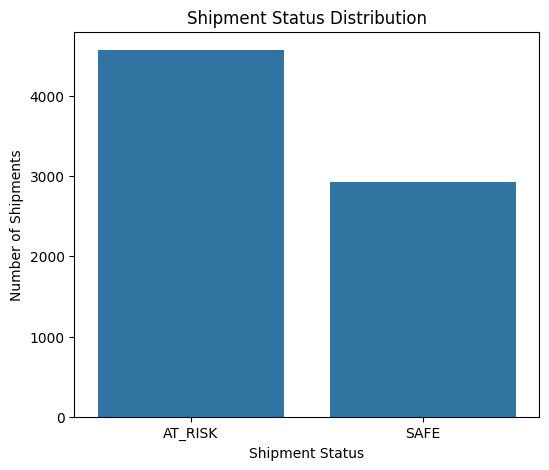

In [96]:
status_counts = df["Shipment_Status"].value_counts()

print(status_counts)

plt.figure(figsize=(6,5))
sns.countplot(data=df, x="Shipment_Status")
plt.title("Shipment Status Distribution")
plt.xlabel("Shipment Status")
plt.ylabel("Number of Shipments")
plt.show()


## 6. Route Risk vs Shipment Status

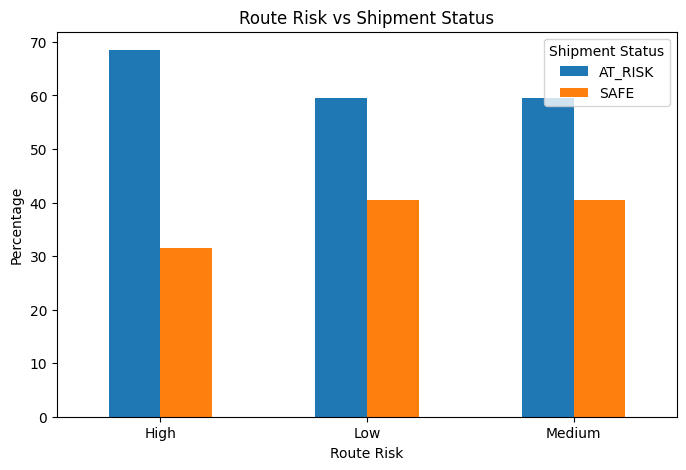

In [97]:
if "Route_Risk" in df.columns:
    route_status = pd.crosstab(
        df["Route_Risk"],
        df["Shipment_Status"],
        normalize="index"
    ) * 100

    route_status.plot(kind="bar", figsize=(8,5))
    plt.title("Route Risk vs Shipment Status")
    plt.xlabel("Route Risk")
    plt.ylabel("Percentage")
    plt.xticks(rotation=0)
    plt.legend(title="Shipment Status")
    plt.show()


## 7. Temperature Deviation vs Shipment Status

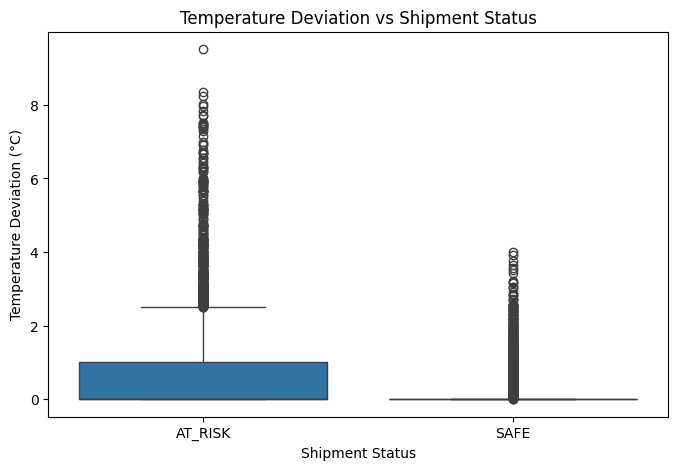

In [98]:
if "Temperature_Deviation_C" in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(
        data=df,
        x="Shipment_Status",
        y="Temperature_Deviation_C"
    )
    plt.title("Temperature Deviation vs Shipment Status")
    plt.xlabel("Shipment Status")
    plt.ylabel("Temperature Deviation (°C)")
    plt.show()


## 8. Door Openings vs Shipment Status

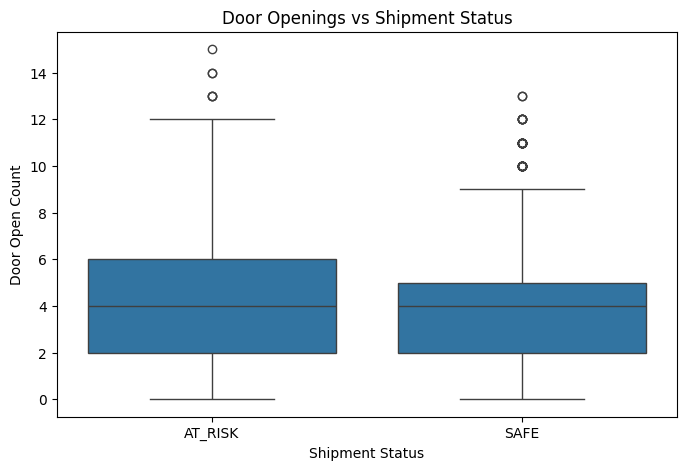

In [99]:
if "Door_Open_Count" in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(
        data=df,
        x="Shipment_Status",
        y="Door_Open_Count"
    )
    plt.title("Door Openings vs Shipment Status")
    plt.xlabel("Shipment Status")
    plt.ylabel("Door Open Count")
    plt.show()


## 9. Correlation Heatmap

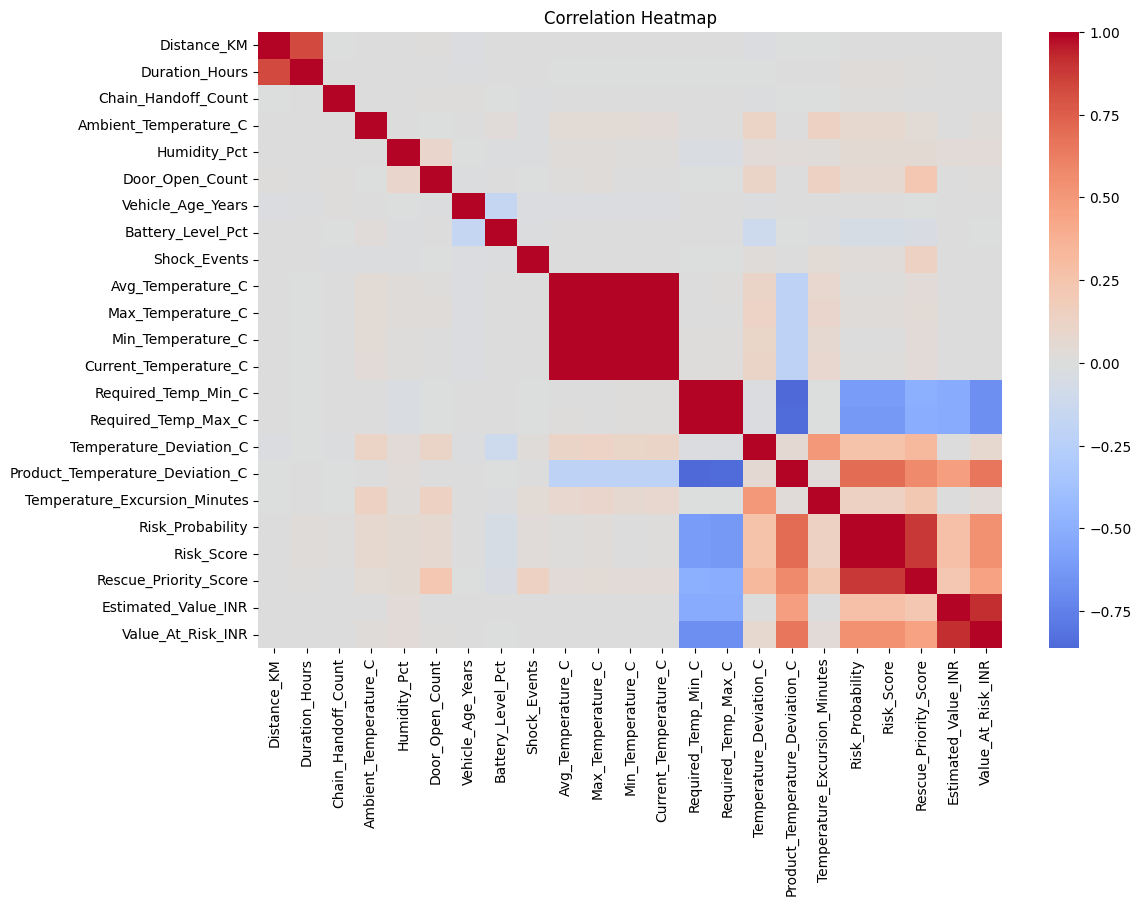

In [100]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()


# 10. Prepare Data for Machine Learning

### Target
`Shipment_Status`

- SAFE
- AT_RISK


In [101]:
TARGET = "Shipment_Status"

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

print("Categorical columns:")
print(X.select_dtypes(include=["object", "category"]).columns.tolist())

Categorical columns:
['Shipment_ID', 'Product_Category', 'Product_Type', 'Destination_Type', 'Transport_Mode', 'Recommended_Transport', 'Route_Risk', 'Refrigeration_Status', 'Packaging_Type', 'Coolant_Type', 'Packaging_Condition', 'Data_Logger_Status', 'Storage_Facility', 'Shipment_Start_Date', 'AI_Prediction', 'Priority_Level', 'Destination_Name']


## 11. Separate Numerical and Categorical Features

In [102]:
# Convert categorical columns into numerical columns
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(
        include=["object", "category"]
    ).columns,
    drop_first=False
)

# Make sure everything is numeric
X = X.astype(float)

# Handle missing values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

print("All features are now numeric.")
print(X.dtypes)

All features are now numeric.
Distance_KM                                   float64
Duration_Hours                                float64
Chain_Handoff_Count                           float64
Ambient_Temperature_C                         float64
Humidity_Pct                                  float64
                                               ...   
Destination_Name_SRL Diagnostics              float64
Destination_Name_Tata Memorial Hospital       float64
Destination_Name_Tata Transplant Center       float64
Destination_Name_Thyrocare Laboratory         float64
Destination_Name_Wellness Forever Pharmacy    float64
Length: 7810, dtype: object


In [103]:
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(
    y.astype(str)
)

print("Target classes:")
print(target_encoder.classes_)

Target classes:
['AT_RISK' 'SAFE']


## 12. Train-Test Split

In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (6000, 7810)
Testing data : (1500, 7810)


# 13. Random Forest Model

**Random Forest** is the only ML model used in this project, as required for the final evaluation.

It combines many decision trees and uses their combined prediction to classify a new shipment.


In [105]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


# 📈 14. Model Evaluation

In [106]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("COLDCHAINGUARD AI - RANDOM FOREST RESULTS")

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")

COLDCHAINGUARD AI - RANDOM FOREST RESULTS
Accuracy  : 91.33%
Precision : 91.42%
Recall    : 91.33%
F1 Score  : 91.36%


## 15. Classification Report

In [107]:
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))


              precision    recall  f1-score   support

           0       0.94      0.92      0.93       914
           1       0.88      0.91      0.89       586

    accuracy                           0.91      1500
   macro avg       0.91      0.91      0.91      1500
weighted avg       0.91      0.91      0.91      1500



## 16. Confusion Matrix

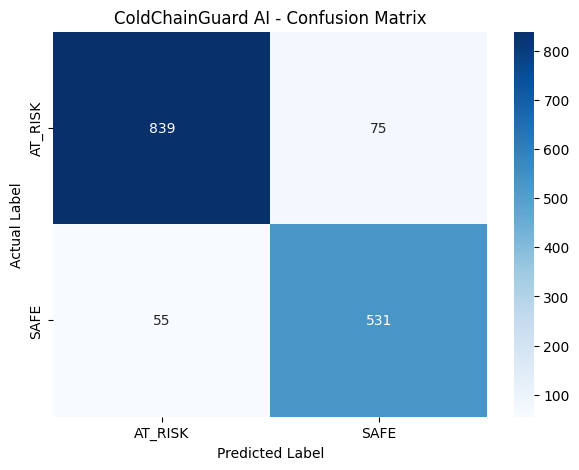

In [108]:
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("ColdChainGuard AI - Confusion Matrix")

plt.show()

## 19. Save the Trained Model

In [109]:
import joblib

joblib.dump(model, "coldchainguard_random_forest.pkl")

print("✅ Model saved with current scikit-learn version")

✅ Model saved with current scikit-learn version


CONCLUSION*

The Cold Chain Guard project provides a smart and secure solution for monitoring temperature-sensitive products during storage and transportation. It monitors temperature data, detects unsafe temperature conditions, and generates alerts when the specified range is exceeded. The project integrates Python, Flask, database technology, data visualization, and blockchain to provide effective monitoring and traceability. The web-based dashboard allows users to view shipment details, temperature trends, alerts, and blockchain records in an easy-to-understand manner. Blockchain technology helps maintain a tamper-evident record of important cold-chain events, improving transparency, accountability, and data security. The system can also be enhanced in the future by integrating IoT sensors such as ESP32 and temperature sensors for real-time monitoring. Overall, Cold Chain Guard improves the reliability, visibility, and security of cold-chain management.